<a href="https://colab.research.google.com/github/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/blob/main/tropicalcyclone_rapidintensification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tropical Cyclone Rapid Intensification (RI) Prediction using Machine Learning

---
**Author(s)**:
Author, Affiliation, Email

> This tutorial is a beginner-friendly walkthrough of predicting Rapid Intensification (RI) in tropical cyclones- the sudden, dangerous jump (>30 knots over 24 hours) in wind speed that makes cyclones so hard to forecast. Using real best-track records, satellite imagery, and atmospheric/oceanic reanalysis data, you'll learn how to frame RI as a rare-event classification problem, train and evaluate a model with metrics suited to imbalanced, safety-critical forecasting, and see how such models could potentially give forecasters more lead time to issue evacuation warnings before a storm suddenly strengthens.

---

# Table of Contents


*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Target Audience](#target-audience)
*   [Background & Prerequisites](#background-and-prereqs)
*   [Software Requirements](#software-requirements)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
*   [Results & Discussion](#results-and-discussion)
*   [References](#references)

---
<a name="overview"></a>
# Overview

In September 2024, Hurricane Helene's winds climbed from 40 kt (45 mph) to 70 kt (80 mph) in a single day, and it came ashore at 120 kt (140 mph) barely a day and a half later. This is know as **Rapid Intensification (RI)**: a sudden, dramatic jump in a cyclone's strength, and one of the hardest problems in operational meteorology to forecast.<a href="#ref1">[1]</a>

This tutorial's goal is to show how Machine Learning can be applied to RI: given a cyclone's state at time *t*, can we predict whether it will intensify by more than 30 knots by *t+24h*? To get there, we'll assemble a multi-modal dataset from best-track records, ERA5 reanalysis fields, and satellite imagery, then train and evaluate a model with an honest eye on both what it gets right and where it falls short.

By the end, you will be able to:
1.  Explain what RI is and why it is difficult to forecast.
2.  Build a multi-modal dataset from best-track records, ERA5 reanalysis fields, and satellite imagery.
3.  Visualize and explore the properties and behavior of tropical cyclones.
4.  Recognize why class imbalance makes standard metrics like accuracy misleading for rare-event problems.
5.  Choose and interpret evaluation metrics suited to rare, high-stakes prediction problems: precision-recall curves, probability of detection, false alarm ratio, and Brier skill score.
6.  Critically assess an ML model's real-world limitations.

Let's get started!

---
<a name="climate-impact"></a>
# Climate Impact

## The problem

Tropical cyclone forecasters have got much better at predicting *where* a storm will go, but predicting *how strong it will get* remains one of the hardest problems in operational meteorology. Predicting rapid intensification remains challenging because it involves complex, interacting processes within the storm and its surrounding environment. Weather models can struggle to capture the small-scale processes near the storm's core, while observations of these processes are often limited.

## The Climate Connection

Rapid intensification is not only a forecasting challenge; it is also relevant to a changing climate. Research suggests that warming oceans and other climate-driven changes are affecting how tropical cyclones intensify:

* **Globally**, studies have found an increase in tropical cyclone intensification rates, with human-caused warming contributing to conditions that can support stronger intensification (Bhatia et al., 2022).
* **Near coastlines**, where rapidly intensifying storms pose a greater risk, the number of RI events occurring within 400 km of the coast has increased substantially since 1980, with ocean warming identified as an important factor (Nature Communications, 2023).
* The **IPCC Sixth Assessment Report** identifies increases in the likelihood of RI in the Atlantic, Northwest Pacific, and globally as a likely detectable signal of human-caused climate change.

## Why Better Rapid Intensification Prediction Matters

Rapid intensification (RI) is more than just a tough weather forecasting problem; it directly determines how much time communities have to prepare and stay safe.

* **Supporting Smarter Emergency Decisions:** Public safety officials and emergency managers rely heavily on intensity forecasts to order evacuations and position emergency teams. Making these forecasts more precise gives vulnerable areas a clearer, more actionable understanding of the risks they face.
* **Saving Lives and Reducing Economic Damage:** Better hurricane forecasting brings real life-saving and economic benefits. NOAA estimates that historical improvements in hurricane forecasting — including intensity forecasting — have reduced fatalities and cut property and crop damage costs by roughly **$2 billion per storm** (2019 dollars), progress driven in large part by the Hurricane Forecast Improvement Program (HFIP).[4]
* **Preparing for Sudden Storm Growth:** Hurricane Otis (2023) is a stark example: it underwent one of the most extreme RI events on record, catching both forecasters and residents of Acapulco off guard. Hurricane Patricia (2015) similarly intensified explosively before making landfall.[5] These disasters show that tracking a storm's path isn't enough. Predicting its actual destructive power is critical for public safety.

## Who uses this, and how

*   **Meteorological agencies** (like NHC/NOAA) issue the forecasts that everyone downstream relies on. Better RI prediction directly improves the accuracy of these public forecasts.
*   **Emergency management officials** use forecast intensity and its confidence to decide evacuation zones, timing, and shelter resource allocation.
*   **Coastal residents and communities** make personal evacuation decisions based on these forecasts; more accurate and earlier RI warnings mean more real lead time to act.
*   **Insurers, infrastructure operators, and disaster-response NGOs** use intensity forecasts to pre-position resources and assess risk exposure ahead of landfall.

## Where this tutorial fits

The tool built in this tutorial does **not** replace operational systems like NOAA's SHIPS-RII or HAFS. Those run on real-time forecast fields, not the reanalysis data (ERA5) we use here (see the Background & Prerequisites and Limitations sections). What this tutorial offers instead is a hands-on, accessible entry point into the *same underlying problem* those operational systems solve: given a cyclone's current state, will it intensify rapidly? Understanding this problem including why it's hard, why standard ML metrics mislead on it, and how to evaluate a model honestly under class imbalance is a transferable skill relevant to anyone who might go on to contribute to real disaster-forecasting pipelines.

---
<a name="target-audience"></a>
# Target Audience

This tutorial is designed for:
*   Beginner-to-intermediate ML practitioners and students with basic Python knowledge, looking for a hands-on example of applying ML to a real-world, climate-relevant forecasting problem. No prior meteorology background is required.
*   Climate scientists and researchers interested in exploring how ML can be applied to a domain-specific forecasting problem they already understand.
*   Anyone working, or hoping to work at the intersection of ML and climate science.

---
<a name="background-and-prerequisites"></a>
# Background and Prerequisites

**Estimated time:** ~2.5 hours  
To follow this tutorial, you should be comfortable with:
*   **Basic Python**: Variables, functions, loops, and using libraries such as `pandas` and `numpy`.
*   **Basic ML concepts**: What a train/validation/test split is and what is binary classification. Some familiarity with `scikit-learn`.
*   **Running notebooks**: This tutorial runs in Google Colab, so no local setup is required. Some familiarity with Jupyter notebooks, such as running cells in order, will be helpful.

**No prior knowledge of meteorology, oceanography, or climate science is required.** The scientific concepts you need are explained below and introduced again when they appear in the tutorial.  
**Run in:** Google Colab (recommended) or any Jupyter environment  

---
# Relevant Videos

The following videos provide additional background on climate change, tropical cyclones, and related forecasting concepts.

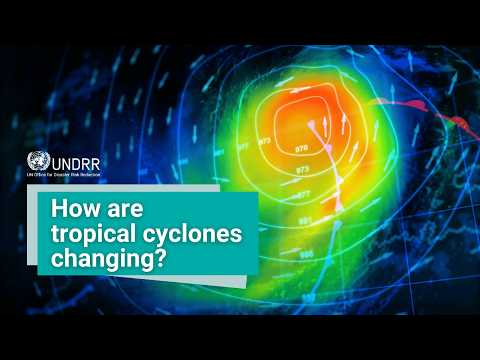

In [ ]:
from IPython.display import YouTubeVideo
YouTubeVideo("LFzIK7GwS3c")

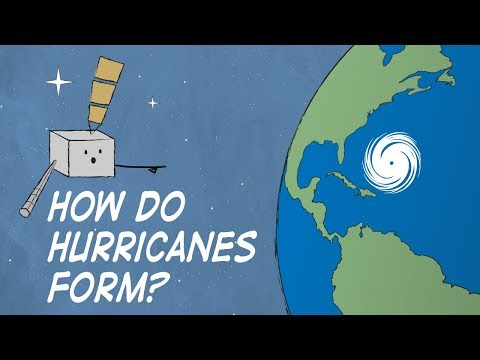

In [ ]:
YouTubeVideo("wPDoIrGUrEc")

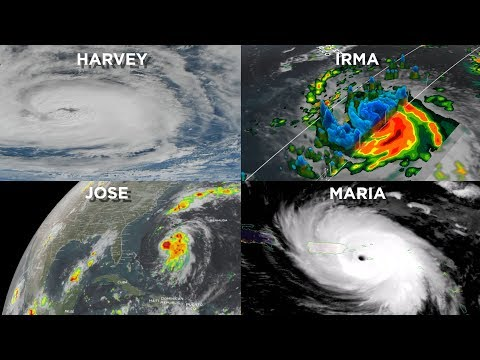

In [ ]:
YouTubeVideo("xZ0Q-1u40lA")

---
<a name="software-requirements"></a>
# Software Requirements
Include in this section the software requirements, setup instructions, and library imports.

Example:

This notebook requires Python >= 3.7. The following libraries are required:

*   pandas==2.2.3
*   numpy==2.2.5
*   matplotlib

All tutorial submissions must have a separate `requirements.txt` file stating all dependencies and versions for software, packages, or tooling used in the tutorial. This file allows tutorial users who would like to run a copy of the notebook locally with all dependencies needed to create their own virtual environment/IPython kernel.

In bash you may create a `requirements.txt` by typing the following command:

`pip freeze > requirements.txt'

Avoid undocumented dependencies.

We encourage explicitly printing out your dependencies using a notebook extension such as [watermark](https://github.com/rasbt/watermark) at the bottom of your notebook.

Within the notebook, there must be a cell which includes the necessary directory structure to retrieve files or data using relative paths for ease of use. If data is private, please provide a similar public sample for those that would like to reproduce or extend your work. Instructions and imports with versioning must be provided and clearly labeled at the top.

Document the beginning and end date of your analysis to contextualize the development stage of the notebook in the event that highlighted packages or content is updated in the future.


---
<a name="software-requirements"></a>
# Software Requirements

This notebook requires **Python 3.13** . The following key libraries are required:

*   numpy==2.5.2
*   pandas==3.0.5
*   xarray==2026.7.0
*   matplotlib==3.11.1
*   plotly==6.9.0
*   Cartopy==0.25.0
*   scikit-learn==1.9.0
*   xgboost==3.4.1
*   ipywidgets==8.1.8

A complete list of all dependencies and exact versions is provided in the accompanying `requirements.txt` file. To set up a local environment:

```bash
pip install -r requirements.txt
```

In [1]:
%pip install -r https://github.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/blob/main/requirements.txt

ERROR: Invalid requirement: '<!DOCTYPE html>': Expected package name at the start of dependency specifier
    <!DOCTYPE html>
    ^ (from line 7 of https://github.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/blob/main/requirements.txt)


## Library Imports

In [ ]:
# ---------------------------------------------------------
# Imports
# ---------------------------------------------------------
import os
import time
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
from pandas.api.types import is_datetime64_any_dtype
import xarray as xr
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import DownloadWarning
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

In [ ]:
# ---------------------------------------------------------
# Environment setup
# ---------------------------------------------------------
os.environ.setdefault("GRPC_VERBOSITY", "ERROR")
os.environ.setdefault("GLOG_minloglevel", "2")
warnings.filterwarnings("ignore", category=DownloadWarning)
pio.renderers.default = "notebook_connected"

In [ ]:
# ---------------------------------------------------------
# Constants
# ---------------------------------------------------------
IBTRACKS_AFTER_1980_CSV_URL = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.since1980.list.v04r01.csv"


---
<a name="data-description"></a>
# Data Description and Exploration

This tutorial combines **IBTrACS v04r01** tropical cyclone best-track data with **ERA5** reanalysis data.

* **IBTrACS:** Global **tabular/CSV** best-track dataset from 1980 onward, with storm observations at approximately **6-hourly intervals**. We use storm location and **USA_WIND** to construct the RI label: a **≥30 kt increase in maximum sustained wind over the next 24 hours**.
  [IBTrACS v04r01](https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/?utm_source=chatgpt.com)

* **ERA5:** Global **gridded reanalysis** at **0.25° × 0.25°** spatial resolution and **hourly** temporal resolution. Environmental variables such as sea-surface temperature and vertical wind shear are matched to each storm observation.
  [ERA5 documentation](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?utm_source=chatgpt.com)


## Data Download

### 1. IBTrACS (International Best Track Archive for Climate Stewardship)

In [ ]:
df = pd.read_csv(
    IBTRACKS_AFTER_1980_CSV_URL,
    delimiter=",",
    header=0,
    skiprows=[1],
    keep_default_na=False,
    low_memory=False,
)

print(f"raw shape: {df.shape}")
df.head()

KeyboardInterrupt: 

### 2. ERA5

## Data Preprocessing
Additionally, you can include any data preprocessing steps and exploratory data analyses (e.g. visualize data distributions, impute missing values, etc.) in this section to allow the users to better understand the dataset. Visualizations should accurately reflect the data and support the central idea of the tutorial while looking professional. For suggestions on good data visualizations please see [Fundamentals of Data Visualizations](https://clauswilke.com/dataviz/).

In this section, you might also want to describe the different input and output variables, the train/val/test splits, and any data transformations.

---
<a name="methodology"></a>
# Methodology

In this section, describe a step-by-step walkthrough of the methodology, in the form of code cells. Feel free to make use of markdown headings to break this section up into smaller subsections, preferrably one section per task.

Reminders:
*   Split the code into small, digestible chunks.
*   Use text cells to describe each code block.
*   Avoid duplicate code through modularization.

Given the sequential nature of notebook cells, if any experiment requires users to rerun previous cells please provide clear and explicit instructions to do so.

## Subtask Heading 1
Replace the heading with the appropriate title for each subtask.

## Rapid intensification

| Section | Stage |
|---|---|
| 1 | Setup |
| 2 | Data loading |
| 3 | Cleaning and filtering |
| 4 | Feature engineering |
| 5 | Target definition |
| 6 | Split and model config |
| 7 | Evaluation helpers |
| 8 | Models |
| 9 | Run |
| A | Appendix — ERA5 from the ARCO public archive (not yet wired in) |


---
<a name="results-and-discussion"></a>
# Results & Discussion

In this section, describe your results. Briefly describe the performance metrics and cross validation techniques used.

Finally, include a discussion on the limitations and important takeaways from the exercise. Relate the takeaways back to the user learning outcomes.

## Limitations
*   ML algorithms and datasets can reinforce or reflect unfair biases. Reflect on the potential biases in the dataset and/or analysis presented in your tutorial, including its potential societal impact, and discuss how you might go about addressing this challenge.

* Additionally, we encourage authors to highlight and reflect upon any data gaps that may be present along with suggested pathways to overcome these gaps as well as steps for further development and usage. To assist with identifying the types of data gaps that could exist please see CCAI's [datagaps taxonomy](https://www.climatechange.ai/dev/datagaps/info#taxonomy-of-data-gaps).

## Next Steps
*   What do you imagine would be the next steps for your readers after finishing your tutorial?
*   Discuss other potential climate-related applications for the method or tool discussed in the tutorial.
*   Do you know of other climate-related datasets similar to the one used in this tutorial? List them here.

---
# References

<a name="ref1">
[1] National Hurricane Center. *Hurricane Helene, 24–27 September 2024: Tropical Cyclone Report.* [NOAA/NHC](https://www.nhc.noaa.gov/data/tcr/AL092024_Helene.pdf)
</a>

[2] Kaplan, J., DeMaria, M., Knaff, J. A., Longmore, S., & Molenar, D. A. (2010). *A Comparison of Statistical and Model-Based Techniques for Predicting Rapid Intensification of Tropical Cyclones.* **Weather and Forecasting, 25**, 1018–1034.

[3] Bhatia, K. et al. *A potential explanation for the global increase in tropical cyclone rapid intensification.* Nature Communications (2022). https://www.nature.com/articles/s41467-022-34321-6

[4] *Recent increases in tropical cyclone rapid intensification events in global offshore regions.* Nature Communications (2023). https://www.nature.com/articles/s41467-023-40605-2

[5] GFDL/NOAA, *Global Warming and Hurricanes* (summary of IPCC AR6 findings on RI attribution). https://www.gfdl.noaa.gov/global-warming-and-hurricanes/

[6] NOAA Science Council, *Hurricanes and Tropical Storms* — economic value of forecast improvements under HFIP. https://sciencecouncil.noaa.gov/noaa-by-the-numbers/hurricane-literature-review-final/

[7] NHC/NOAA storm reports for Hurricane Patricia (2015) and Hurricane Otis (2023).

### 🔄 Try it yourself: Wind speed converter and storm category finder

RI is defined as a **30-knot increase in maximum sustained wind over 24 hours**. Enter different wind speeds in **knots** value below to see the equivalent **mph, km/h, and m/s**, along with the corresponding storm category.

In [ ]:
# ---------------------------------------------------------
# Environment setup
# ---------------------------------------------------------
os.environ.setdefault("GRPC_VERBOSITY", "ERROR")
os.environ.setdefault("GLOG_minloglevel", "2")
warnings.filterwarnings("ignore", category=DownloadWarning)
pio.renderers.default = "notebook_connected"

In [ ]:
# Wind Speed Explorer — knots, mph, km/h, m/s, and storm category
# ----------------------------------------------------------------

import ipywidgets as widgets
from IPython.display import display

CATEGORIES = [
    (0, "Tropical Depression"), (34, "Tropical Storm"),
    (64, "Category 1"), (83, "Category 2"), (96, "Category 3"),
    (113, "Category 4"), (137, "Category 5")
]

CATEGORY_COLORS = {
    "Tropical Depression": "#6EC1EA", "Tropical Storm": "#4DFFFF",
    "Category 1": "#FFFFD9", "Category 2": "#FFD98C", "Category 3": "#FF9E59",
    "Category 4": "#FF738A", "Category 5": "#A188FC"
}

RECORD_KT = 185  # Hurricane Patricia, 2015

def category_for(knots):
    return next(label for threshold, label in reversed(CATEGORIES) if knots >= threshold)

def legend_html(current):
    return "".join(
        f'<div style="font-weight:{"bold" if label == current else "normal"};">'
        f'{"→ " if label == current else "&nbsp;&nbsp;&nbsp;"}'
        f'<span style="display:inline-block;width:14px;height:14px;background:{CATEGORY_COLORS[label]};'
        f'border:{"2px solid #000" if label == current else "1px solid #999"};'
        f'vertical-align:middle;margin-right:6px;"></span>{label}</div>'
        for _, label in CATEGORIES
    )

value_input = widgets.FloatText(value=30.0, description="Wind (kt):")
result = widgets.HTML()

def convert(_=None):
    kt = value_input.value
    mph, kmh, ms = kt * 1.15078, kt * 1.852, kt * 0.514444
    category = category_for(kt)
    ri_note = "meets" if kt >= 30 else "does not meet"
    record_note = f"<br><i>Exceeds the ~{RECORD_KT} kt maximum sustained wind recorded for Hurricane Patricia (2015).</i>" if kt > RECORD_KT else ""

    result.value = f"""
    <div style="font-family:monospace;line-height:1.6;">
    <b>{kt:.1f} kt</b> = {mph:.1f} mph = {kmh:.1f} km/h = {ms:.1f} m/s
    <br><br>As a <b>current wind speed</b>: {category}{record_note}
    <br><br><b>Storm Categories</b> (<a href="https://en.wikipedia.org/wiki/Saffir%E2%80%93Simpson_scale" target="_blank" style="text-decoration:underline;">Saffir–Simpson scale</a>; current speed marked): {legend_html(category)}
    <br>As a <b>24-hour wind-speed increase</b>: {ri_note} the 30 kt <b>Rapid Intensification</b> threshold.
    </div>
    """

value_input.observe(convert, names="value")
convert()
display(widgets.VBox([value_input, result]))

## 1. Setup

## 2. Data loading

IBTrACS v04r01, all basins, 1980 onward, straight from NOAA NCEI. Row 1 of the CSV
is a units row, not data, hence `skiprows=[1]`. `keep_default_na=False` keeps the
basin code `"NA"` (North Atlantic) from being read as NaN.

In [ ]:
CSV_PATH = "all_basins_since_1980.csv"

df = pd.read_csv(
    CSV_PATH,
    delimiter=",",
    header=0,
    skiprows=[1],
    keep_default_na=False,
    low_memory=False,
)
df.columns = df.columns.str.lower().str.strip()

print(f"raw shape: {df.shape}")
df.head()

raw shape: (308328, 174)


,sid,season,number,basin,subbasin,name,iso_time,nature,lat,lon,...,bom_gust_per,reunion_gust,reunion_gust_per,usa_seahgt,usa_searad_ne,usa_searad_se,usa_searad_sw,usa_searad_nw,storm_speed,storm_dir
0,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 00:00:00,TS,-12.5,172.5,...,,,,,,,,,6,350
1,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 03:00:00,TS,-12.2,172.4,...,,,,,,,,,6,350
2,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 06:00:00,TS,-11.9,172.4,...,,,,,,,,,5,360
3,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 09:00:00,TS,-11.7,172.4,...,,,,,,,,,4,10
4,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 12:00:00,TS,-11.5,172.5,...,,,,,,,,,4,20


## 3. Cleaning and filtering

### 3.1 Type coercion

In [ ]:
# Strip whitespace from every text column
obj_cols = df.select_dtypes(include=["object", "str"]).columns
df[obj_cols] = df[obj_cols].apply(lambda s: s.str.strip())

# Datetime
df["iso_time"] = pd.to_datetime(df["iso_time"], errors="coerce")

# Numeric
NUMERIC_COLS = [
    "season",
    "lat",
    "lon",
    "usa_wind",
    "dist2land",
    "storm_speed",
]

for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["lon"] = df["lon"] % 360

### 3.2 Add basin names as metadata

In [ ]:
BASIN_NAMES = {
    "NA": "North Atlantic",
    "EP": "Eastern North Pacific",
    "WP": "Western North Pacific",
    "NI": "North Indian",
    "SI": "South Indian",
    "SP": "Southern Pacific",
    "SA": "South Atlantic",
}

# Useful later for plotting
BASIN_COLOR = {
    "NA": "#C85A5A",
    "EP": "#5B82B0",
    "WP": "#D18A45",
    "NI": "#8066A6",
    "SI": "#6FA35F",
    "SP": "#9A684F",
    "SA": "#B85F8A",
}

df["full_basin_name"] = df["basin"].map(BASIN_NAMES)

### 3.3 Row filter

Documentation: https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf

Keep only rows that are usable as forecast points:

- `track_type == "main"` — drop spur tracks and provisional (not yet best-tracked) storms
- `nature == "TS"` — tropical systems only, no extratropical or disturbance rows
- synoptic times only (00/06/12/18 UTC, on the hour)
- `usa_wind` present and positive
- first character of `iflag` (the USA agency flag) is `O` or `V` — observed, or
  interpolated from observed values, rather than position/intensity-only interpolation

In [ ]:
MASK = (
    (df["track_type"].str.lower() == "main")
    & (df["nature"].astype(str).str.upper().str.strip() == "TS")
    & (df["iso_time"].dt.hour.isin([0, 6, 12, 18]))
    & (df["iso_time"].dt.minute == 0)
    & (df["usa_wind"].notna())
    & (df["usa_wind"] > 0)
    & (df["iflag"].str[0].isin(["O", "V"]))
    & (df['season'] <= 2025)
)

df = df[MASK]
df = df.replace(r"^\s*$", np.nan, regex=True)

KEEP_COLS = [
    "sid", "season", "basin", "full_basin_name", "subbasin", "name",
    "iso_time", "lat", "lon",
    "nature", "track_type", "iflag", "usa_agency",
    "usa_wind", "usa_sshs",
    "dist2land",
    "storm_speed"
]

df = df[KEEP_COLS].copy()
df = df.sort_values(["sid", "iso_time"]).reset_index(drop=True)

print(f"after filter: {df.shape}  storms={df.sid.nunique():,}  "
      f"seasons {int(df.season.min())}–{int(df.season.max())}")

after filter: (103173, 17)  storms=4,255  seasons 1980–2025


### 3.4 Post-filter checks

In [ ]:
missing = df[KEEP_COLS].isna().sum().sort_values(ascending=False)
print(missing)

sid                0
nature             0
dist2land          0
usa_sshs           0
usa_wind           0
usa_agency         0
iflag              0
track_type         0
lon                0
season             0
lat                0
iso_time           0
name               0
subbasin           0
full_basin_name    0
basin              0
storm_speed        0
dtype: int64


In [ ]:
# Observation cadence — should be overwhelmingly 6h.
# Anything else means the time-shift lookups will miss more rows than expected.
gaps = df.groupby("sid").iso_time.diff().dropna()
print(gaps.value_counts().head())

iso_time
0 days 06:00:00    98422
0 days 12:00:00      205
0 days 18:00:00       94
1 days 00:00:00       48
1 days 12:00:00       25
Name: count, dtype: int64


In [ ]:
df.head()

,sid,season,basin,full_basin_name,subbasin,name,iso_time,lat,lon,nature,track_type,iflag,usa_agency,usa_wind,usa_sshs,dist2land,storm_speed
0,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 00:00:00,-12.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,647,6.0
1,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 06:00:00,-11.9,172.4,TS,main,O_________OP_O_,jtwc_sh,25.0,-1,670,5.0
2,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 12:00:00,-11.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,703,4.0
3,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 18:00:00,-11.2,172.7,TS,main,O_________OP_O_,jtwc_sh,30.0,-1,741,3.0
4,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-02 00:00:00,-11.2,173.0,TS,main,O________OOO_O_,jtwc_sh,30.0,-1,767,3.0


### 3.5 A look at the tracks

The four strongest storms per basin (by peak `usa_wind`), as a sanity check that
the filtered tracks look like tropical cyclones.

In [ ]:
C = {"track": "#AAB4BC", "ink": "#33383D", "grid": "#E4E7EA",
     "land": "#DCEAD9", "ocean": "#CFE3F0", "coast": "#8FA69B", "lake": "#CFE3F0"}


def geo_layout(fig, title, height=600):
    fig.update_geos(
        projection_type="natural earth",
        showland=True, landcolor=C["land"],
        showocean=True, oceancolor=C["ocean"],
        showlakes=True, lakecolor=C["lake"],
        showcoastlines=True, coastlinecolor=C["coast"], coastlinewidth=0.5,
        showcountries=False,
        lataxis=dict(range=[-60, 60], showgrid=True, dtick=15,
                     gridcolor="white", gridwidth=0.6),
        lonaxis=dict(showgrid=True, dtick=30,
                     gridcolor="white", gridwidth=0.6),
    )
    fig.update_layout(
        title=title, height=height, margin=dict(l=0, r=0, t=70, b=0),
        legend=dict(yanchor="bottom", y=0.02, xanchor="left", x=0.02,
                    bgcolor="rgba(255,255,255,0.82)"),
    )
    return fig

In [ ]:
# Select the strongest storms in each basin
N_PER_BASIN = 4

top = (
    df.groupby(["basin", "sid"])["usa_wind"]
      .max()
      .reset_index(name="peak_wind")
      .sort_values("peak_wind", ascending=False)
      .groupby("basin")
      .head(N_PER_BASIN)
)

top_storms = df.merge(
    top[["basin", "sid"]],
    on=["basin", "sid"]
).sort_values(["sid", "iso_time"])

# Plot the tracks
fig = go.Figure()

for sid, storm in top_storms.groupby("sid"):

    storm = storm.sort_values("iso_time")
    basin = storm.basin.iloc[0]
    color = BASIN_COLOR[basin]

    name = storm.name.dropna().iloc[0].title() if storm.name.notna().any() else sid

    # Track
    fig.add_trace(go.Scattergeo(
        lon=storm.lon,
        lat=storm.lat,
        mode="lines+markers",
        line=dict(width=1, color=color),
        marker=dict(size=3, color=color),
        text=storm.iso_time.dt.strftime("%Y-%m-%d %H:%M UTC"),
        hovertemplate=(
            f"<b>{name}</b><br>"
            "%{text}<br>"
            "Wind: %{customdata} kt<br>"
            "Latitude: %{lat:.1f}°<br>"
            "Longitude: %{lon:.1f}°"
            "<extra></extra>"
        ),
        customdata=storm.usa_wind.round(0),
        showlegend=False
    ))

    # Storm name + genesis point
    fig.add_trace(go.Scattergeo(
        lon=[storm.lon.iloc[0]],
        lat=[storm.lat.iloc[0]],
        mode="markers+text",
        text=[name],
        textposition="top center",
        marker=dict(size=7, symbol="circle-open", color=color),
        textfont=dict(size=9, color=color),
        showlegend=False,
        hoverinfo="skip"
    ))


geo_layout(
    fig,
    f"Top {N_PER_BASIN} most intense tropical storms (TS) by the maximum speed attained per basin<br>"
    "<sub>Circle = genesis · hover for details · zoom in and out to inspect </sub>",
    height=680
).show()

## 4. Feature engineering

### 4.1 Cyclical coordinates

Latitude and longitude are angular coordinates. Longitude wraps around at the
dateline, so values near `0°` and `360°` represent nearby locations even though
their raw numerical values are far apart. Sine/cosine pairs encode each angular
coordinate on a circle, removing this artificial discontinuity.

`abs_lat` captures distance from the equator while discarding the hemisphere
sign, allowing the model to represent similar latitudinal positions north and
south of the equator.


In [ ]:
def add_cyclical_coords(df, lat_col="lat", lon_col="lon"):
    '''Sin/cos encodings for lat and lon, plus abs_lat.
    Does not mutate the input. Safe to re-run: output columns are replaced.
    '''
    generated = ["lat_sin", "lat_cos", "lon_sin", "lon_cos", "abs_lat"]
    out = df.drop(columns=generated, errors="ignore").copy()

    lat_rad = np.deg2rad(df[lat_col])
    lon_rad = np.deg2rad(df[lon_col])

    out["lat_sin"] = np.sin(lat_rad)
    out["lat_cos"] = np.cos(lat_rad)
    out["lon_sin"] = np.sin(lon_rad)
    out["lon_cos"] = np.cos(lon_rad)
    out["abs_lat"] = df[lat_col].abs()

    return out

### 4.2 Seasonal coordinates

Day-of-year is cyclic too. Southern Hemisphere dates are shifted by half a year
so that the two hemispheres' cyclone seasons line up.

In [ ]:
def add_seasonal_coords(df, time_col="iso_time", lat_col="lat"):
    '''Add cyclic day-of-year features.

    Southern Hemisphere dates are shifted by half a year so that comparable
    cyclone seasons in the Northern and Southern Hemispheres have similar
    seasonal coordinates.

    Does not mutate the input. Safe to re-run: output columns are replaced.
    '''
    generated = ["doy_sin", "doy_cos"]
    out = df.drop(columns=generated, errors="ignore").copy()

    doy = out[time_col].dt.dayofyear.astype(float)

    # Shift Southern Hemisphere dates by half a year.
    # This approximately aligns South Hemisphere February with North Hemisphere August.
    shift = np.where(out[lat_col] < 0, 365.25 / 2, 0)

    doy = (doy + shift) % 365.25

    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

    return out

### 4.3 Time-shifted values and the past intensity trend

One helper looks up the value of a column at `t + hours` for the same storm, using
absolute time rather than row offsets, so irregular spacing and gaps produce `NaN`
instead of a wrong neighbour.

It serves two purposes:

- **Backward** (`hours < 0`): the wind change over the *previous* 6/12/24 h. A
  storm that is already strengthening is far more likely to keep going — this is
  the single most important predictor in operational RI schemes such as SHIPS-RII,
  and it is leak-free because it only looks into the past.
- **Forward** (`hours > 0`): the wind at `t + 24 h`, which defines the label in
  section 5.

Rows near the start of a track have no past value; XGBoost handles the `NaN`
natively and the logistic regression gets a median imputer.

In [ ]:
def offset_column_name(col, hours):
    '''hours < 0 is the past: ('usa_wind', -6) -> 'usa_wind_tminus6h'.'''
    return f"{col}_t{'plus' if hours > 0 else 'minus'}{abs(hours)}h"

def add_value_at_offset(df, col, hours, storm="sid", time="iso_time"):
    '''Add the value of `col` from `hours` hours away in the same storm.
    Negative looks back, positive looks forward. NaN when that storm has no
    observation at exactly that time. Does not mutate input, preserves row order.'''
    if not is_datetime64_any_dtype(df[time]):
        raise TypeError(f"{time!r} is {df[time].dtype}, expected datetime64. Run pd.to_datetime first.")
    offset_col = offset_column_name(col, hours)
    target_time = "_target_time"
    out = df.drop(columns=[offset_col, target_time], errors="ignore")
    repeats = out.duplicated([storm, time])
    if repeats.any():
        raise ValueError(f"{int(repeats.sum())} rows repeat a ({storm}, {time}) pair. Check the track_type filter.")
    lookup = out[[storm, time, col]].rename(columns={time: target_time, col: offset_col})
    out[target_time] = out[time] + pd.Timedelta(hours=hours)
    return out.merge(lookup, on=[storm, target_time], how="left", validate="one_to_one").drop(columns=[target_time])

def add_change_over_past_hours(df, col="usa_wind", lags=(6, 12, 24), **keys):
    '''Add the change in `col` over each of the previous `lags` hours.'''
    out = df.copy()
    for hours in lags:
        out = add_value_at_offset(out, col, -hours, **keys)
        out[f"{col}_delta_tminus{hours}h"] = out[col] - out[offset_column_name(col, -hours)]
    return out

## 5. Target definition

RI is a property of a **(storm, time)** pair, not of a storm. Each row asks:
*from this moment, does the wind gain ≥ 30 kt over the next 24 hours?*

Rows in the last 24 hours of a track have no answer and get `NaN`. That costs
roughly 4 rows per storm and is expected.

In [ ]:
def ri_label_name(hours=HORIZON_H):
    return f"ri_tplus{hours}"

TARGET = ri_label_name()

def add_ri_label(df, col="usa_wind", hours=HORIZON_H, threshold_kt=RI_THRESHOLD_KT, **keys):
    '''Add the forward change in `col` and the binary RI label. NA where the future value is unknown.'''
    delta_col = f"{col}_delta_tplus{hours}h"
    label_col = ri_label_name(hours)
    out = add_value_at_offset(df, col, hours, **keys).drop(columns=[delta_col, label_col], errors="ignore")
    out[delta_col] = out[offset_column_name(col, hours)] - out[col]
    out[label_col] = (out[delta_col] >= threshold_kt).astype("Int64").where(out[delta_col].notna())
    return out

In [ ]:
df = add_cyclical_coords(df)
df = add_seasonal_coords(df)
df = add_change_over_past_hours(df, "usa_wind", lags=(6, 12, 24))
df = add_ri_label(df, "usa_wind")

print(df[TARGET].value_counts(dropna=False))

ri_tplus24
0       79281
<NA>    17619
1        6273
Name: count, dtype: Int64


In [ ]:
# Drop rows where the 24-hour RI label cannot be determined
n_before = len(df)
ml_df = df[df[TARGET].notna()].copy().reset_index(drop=True)
n_lost = n_before - len(ml_df)

print(f"Rows: {n_before:,} → {len(ml_df):,}")
print(f"Rows removed: {n_lost:,}")
print(f"Unique tropical storms in the final dataframe: {ml_df['sid'].nunique():,}")

print("\nRapid Intensification (RI) event distribution:")
print(ml_df[TARGET].value_counts(dropna=False))
print(ml_df[TARGET].value_counts(normalize=True))

Rows: 103,173 → 85,554
Rows removed: 17,619
Unique tropical storms in the final dataframe: 4,165

Rapid Intensification (RI) event distribution:
ri_tplus24
0    79281
1     6273
Name: count, dtype: Int64
ri_tplus24
0    0.926678
1    0.073322
Name: proportion, dtype: Float64


In [ ]:
ml_df.columns

Index(['sid', 'season', 'basin', 'full_basin_name', 'subbasin', 'name',
       'iso_time', 'lat', 'lon', 'nature', 'track_type', 'iflag', 'usa_agency',
       'usa_wind', 'usa_sshs', 'dist2land', 'storm_speed', 'lat_sin',
       'lat_cos', 'lon_sin', 'lon_cos', 'abs_lat', 'doy_sin', 'doy_cos',
       'usa_wind_tminus6h', 'usa_wind_delta_tminus6h', 'usa_wind_tminus12h',
       'usa_wind_delta_tminus12h', 'usa_wind_tminus24h',
       'usa_wind_delta_tminus24h', 'usa_wind_tplus24h',
       'usa_wind_delta_tplus24h', 'ri_tplus24'],
      dtype='str')

In [ ]:
print("overall RI rate:", ml_df[TARGET].mean().round(4))
print()
print(ml_df.groupby("basin")[TARGET].agg(["mean", "sum", "size"]).round(4))

overall RI rate: 0.0733

         mean   sum   size
basin                     
EP     0.0765  1260  16481
NA     0.0614   779  12680
NI     0.0665   201   3022
SA        0.0     0      7
SI     0.0639  1119  17521
SP     0.0712   637   8949
WP     0.0847  2277  26894


In [ ]:
# How often is the past-trend feature available?
for lag in (6, 12, 24):
    c = f"usa_wind_delta_tminus{lag}h"
    print(f"{c:22s} available for {ml_df[c].notna().mean():.1%} of rows")

usa_wind_delta_tminus6h available for 94.8% of rows
usa_wind_delta_tminus12h available for 89.9% of rows
usa_wind_delta_tminus24h available for 80.7% of rows


### Final dataframe after feature engineering and target definition

In [ ]:
ml_df.head(3)

,sid,season,basin,full_basin_name,subbasin,name,iso_time,lat,lon,nature,...,doy_cos,usa_wind_tminus6h,usa_wind_delta_tminus6h,usa_wind_tminus12h,usa_wind_delta_tminus12h,usa_wind_tminus24h,usa_wind_delta_tminus24h,usa_wind_tplus24h,usa_wind_delta_tplus24h,ri_tplus24
0,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 00:00:00,-12.5,172.5,TS,...,-0.999852,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.0,0
1,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 06:00:00,-11.9,172.4,TS,...,-0.999852,25.0,0.0,NaN,NaN,NaN,NaN,30.0,5.0,0
2,1980001S13173,1980,SP,Southern Pacific,MM,PENI,1980-01-01 12:00:00,-11.5,172.5,TS,...,-0.999852,25.0,0.0,25.0,0.0,NaN,NaN,35.0,10.0,0


## 6. Split and model config

`usa_wind_tplus24h`, `usa_wind_delta_p24h` and the label itself are the label in
disguise. The `LEAK` set exists so that an assertion fails loudly if any of them
ever gets added to a feature list.

Two feature sets are kept: `FEATURES_BASE` is the original position/intensity-only
set, reported as an ablation; `FEATURES` adds the past intensity trend and the
seasonal coordinates.

In [ ]:
FEATURES_BASE = [
    "usa_wind",
    "dist2land",
    "storm_speed",
    "abs_lat",
    "lon_sin", "lon_cos",
    "lat_sin", "lat_cos",
]  # + basin one-hot, appended in prepare()

FEATURES = FEATURES_BASE + [
    "usa_wind_delta_tminus6h",   # past intensity trend (backward-looking only)
    "usa_wind_delta_tminus12h",
    "usa_wind_delta_tminus24h",
    "doy_sin", "doy_cos",   # seasonal coordinates
]


LEAK = {
    offset_column_name("usa_wind", HORIZON_H),   # usa_wind_tplus24h
    f"usa_wind_delta_tplus{HORIZON_H}h",           # usa_wind_delta_tplus24h
    TARGET,                                    # ri_tplus24
}

In [ ]:
def prepare(df):
    '''Attach basin one-hots and return (frame, base feature list, full feature list).'''
    df = df.copy()
    df = df.sort_values(["sid", "iso_time"]).reset_index(drop=True)

    basin = pd.get_dummies(df.basin, prefix="basin", dtype=int)
    df = pd.concat([df, basin], axis=1)

    feats_base = FEATURES_BASE + list(basin.columns)
    feats = FEATURES + list(basin.columns)
    for f in (feats_base, feats):
        assert not (set(f) & LEAK), "leakage column in feature list"
    return df, feats_base, feats


def split(df):
    '''Chronological split by season. Never split randomly: storms are correlated
    within a season and a random split would leak.'''
    train = df[df.season <= TRAIN_END]
    validation = df[(df.season > TRAIN_END) & (df.season <= VAL_END)]
    test = df[(df.season > VAL_END) & (df.season <= TEST_END)]

    # Pairwise, not three-way: a two-way overlap must also fail
    assert not set(train.sid) & set(validation.sid), "train/val storm overlap"
    assert not set(train.sid) & set(test.sid), "train/test storm overlap"
    assert not set(validation.sid) & set(test.sid), "val/test storm overlap"

    for name, d in [("train", train), ("val", validation), ("test", test)]:
        print(f"{name:6s} seasons {int(d.season.min())}–{int(d.season.max())}  "
              f"rows={len(d):7,d}  storms={d.sid.nunique():5,d}  "
              f"ri_rate={d[TARGET].mean():.4f}")
    return train, validation, test

## 7. Evaluation helpers

We use **three families of metrics**, because each answers a different
question about the RI forecast.

| Metric | Full name | What it tells us |
|---|---|---|
| **ROC-AUC** | Receiver Operating Characteristic – Area Under the Curve | How well does the model separate RI from non-RI across thresholds? |
| **PR-AUC** | Precision–Recall Area Under the Curve | How well does the model identify the relatively rare RI events? |
| **BSS** | Brier Skill Score | Are the predicted probabilities accurate compared with a baseline? |
| **POD (Recall)** | Probability of Detection | Of all actual RI events, how many did we detect? |
| **FAR** | False Alarm Ratio | Of all predicted RI events, how many were false alarms? |
| **CSI** | Critical Success Index | How well does the model detect RI while accounting for misses and false alarms? |
| **PSS** | Peirce Skill Score | How much better is the model at distinguishing RI from non-RI than random guessing? |

### Why do we need several metrics?

A model can **rank RI events well** without producing accurate probabilities.
It can also have good overall discrimination while producing too many false
alarms at the threshold we actually use.

So we evaluate the model from three perspectives:

1. **Ranking:** ROC-AUC and PR-AUC
2. **Probability quality:** BSS
3. **Operational performance:** Recall, FAR, CSI and PSS

### Why is PR-AUC especially important here?

Rapid intensification (RI) is a relatively **rare event** in our dataset.
Only ~7% of observations are RI (6.6% in the training seasons, ~9% in the
validation and test seasons), so a model that predicts "no RI" almost
everywhere can still achieve high accuracy.

PR-AUC is therefore particularly useful because it focuses on the model's
ability to identify the **positive class (RI)** while accounting for false
alarms.

The **no-skill PR-AUC baseline is approximately the RI base rate**.

For example, if RI occurs in ~9% of observations:

| PR-AUC | Rough interpretation |
|---:|---|
| ~0.09 | No better than a no-skill baseline |
| 0.15 | Some discrimination |
| 0.30 | Substantial improvement over baseline |
| 1.00 | Perfect ranking |

### Why the Brier skill score needs unweighted models

Class reweighting (`class_weight="balanced"`, `scale_pos_weight`) can help a
model *rank* rare events, but it deliberately inflates every predicted
probability. The ranking metrics don't care, the Brier score does: a reweighted
model scores far worse than climatology (BSS ≈ −1) even when its ROC-AUC is
good. This notebook therefore trains without reweighting, reads BSS as a real
probability-quality measure, and adds an isotonic calibration step fitted on
validation on top.

> **Key idea:** There is no single "best" metric. PR-AUC tells us about
> ranking rare RI events, BSS tells us about probability quality, and
> Recall/FAR/CSI tell us what the forecast actually looks like at a chosen
> operating threshold.

### One more important distinction

**ROC-AUC and PR-AUC do not require us to choose a threshold.**

They evaluate predictions across many possible thresholds.

In contrast, metrics such as **Recall, FAR, CSI and PSS require a threshold**.
The threshold is chosen on **validation** only (F1-optimal), and the test set is
scored once at that threshold.

In [ ]:
def evaluate(name, y, p, base_rate):
    '''Ranking metrics plus the Brier SKILL score: improvement over always
    predicting the base rate. Returns a dict so results can be tabulated.'''
    y = np.asarray(y).astype(int)
    p = np.asarray(p, dtype=float)
    bs_model = brier_score_loss(y, p)
    bs_clim = brier_score_loss(y, np.full_like(p, base_rate))
    row = dict(
        model=name,
        pr_auc=average_precision_score(y, p),
        roc_auc=roc_auc_score(y, p),
        bss= 1 - bs_model / bs_clim,
    )
    print(f"{name:28s} PR-AUC={row['pr_auc']:.4f}  "
          f"ROC-AUC={row['roc_auc']:.4f}  BSS={row['bss']:+.4f}")
    return row


def confusion(y, p, thr, title=""):
    y, p = np.asarray(y).astype(int), np.asarray(p)
    yhat = (p >= thr).astype(int)

    tn, fp, fn, tp = map(int, confusion_matrix(
        y, yhat, labels=[0, 1]
    ).ravel())

    recall = tp / (tp + fn) if tp + fn else 0
    far = fp / (tp + fp) if tp + fp else 0
    pofd = fp / (fp + tn) if fp + tn else 0
    prec = tp / (tp + fp) if tp + fp else 0
    f1 = 2 * prec * recall / (prec + recall) if prec + recall else 0
    csi = tp / (tp + fp + fn) if tp + fp + fn else 0
    pss = recall - pofd

    print(f"\n{title} (threshold={thr:.3f})")
    print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
    print(
        f"Precision={prec:.3f}  Recall={recall:.3f}"
        f"   F1={f1:.3f}  FAR={far:.3f}"
        f"   CSI={csi:.3f}  PSS={pss:.3f}"
        f"   POFD={pofd:.3f}"
    )


def best_threshold(y, p):
    '''F1-optimal threshold, chosen on VALIDATION only.

    precision_recall_curve returns len(thr) == len(prec) - 1, so f1 is
    truncated to align.
    '''
    prec, rec, thr = precision_recall_curve(y, p)
    f1 = 2 * prec * rec / np.clip(prec + rec, 1e-9, None)
    return float(thr[np.nanargmax(f1[:-1])])

## 8. Models

Climatology (always predict the training base rate), logistic regression, and
XGBoost with early stopping on validation PR-AUC. None of them reweight classes,
so their probabilities are directly comparable to climatology via BSS.

`calibrate()` fits an isotonic mapping from raw XGBoost scores to observed RI
frequency on the validation set; it never sees test.

In [ ]:
def fit_climatology(Xtr, ytr):
    return DummyClassifier(strategy="prior").fit(Xtr, ytr)


def fit_logit(Xtr, ytr):
    return Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000)),
    ]).fit(Xtr, ytr)


def fit_xgb(Xtr, ytr, Xva, yva):
    return XGBClassifier(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=10,
        reg_lambda=2.0,
        eval_metric="aucpr",
        early_stopping_rounds=40,
        n_jobs=-1,
        random_state=SEED,
    ).fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)


def calibrate(p_val, y_val):
    '''Isotonic calibration fitted on validation scores.'''
    return IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0).fit(p_val, y_val)


def report_operating_points(yte, pte, quantiles=(0.30, 0.50, 0.70, 0.90, 0.95)):
    print("\n--- operating points (test) ---")
    print(f"{'thr':>6} {'Recall':>7} {'FAR':>7} {'CSI':>7} {'alarms':>8}")
    for q in quantiles:
        t = float(np.quantile(pte, q))
        yh = (pte >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(yte, yh, labels=[0, 1]).ravel()
        print(f"{t:6.3f} {tp / max(tp + fn, 1):7.3f} "
              f"{fp / max(tp + fp, 1):7.3f} "
              f"{tp / max(tp + fp + fn, 1):7.3f} {int(yh.sum()):8,d}")


def report_per_basin(te, yte, pte, min_events=5):
    print("\n--- per-basin (test) ---")
    yte = np.asarray(yte)
    for b, idx in te.groupby("basin").groups.items():
        m = te.index.isin(idx)
        if yte[m].sum() >= min_events:
            print(f"  {b}  n={m.sum():6,d}  ri={int(yte[m].sum()):4d}  "
                  f"PR-AUC={average_precision_score(yte[m], pte[m]):.4f}")


def report_leakage_check(Xtr, ytr, Xva, yva, base):
    '''Shuffle the training labels. A healthy pipeline collapses to baseline:
    ROC-AUC ~ 0.5, PR-AUC ~ base rate, BSS ~ 0.'''
    print("\n--- leakage check: shuffled labels ---")
    rng = np.random.default_rng(SEED)
    ysh = pd.Series(rng.permutation(ytr.values), index=ytr.index)
    xsh = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05,
        n_jobs=-1, random_state=SEED,
    ).fit(Xtr, ysh)
    evaluate("shuffled (want ~base)", yva, xsh.predict_proba(Xva)[:, 1], base)

## 9. Run

### 9.1 Split and validation comparison

In [ ]:
data, features_base, features = prepare(ml_df)
train, val, test = split(data)

ytr = train[TARGET].astype(int)
yva = val[TARGET].astype(int)
yte = test[TARGET].astype(int)

base = ytr.mean()
print(f"\ntraining base rate: {base:.4f}")

train  seasons 1980–2010  rows= 62,141  storms=2,849  ri_rate=0.0657
val    seasons 2011–2015  rows=  8,081  storms=  437  ri_rate=0.0923
test   seasons 2016–2025  rows= 15,332  storms=  879  ri_rate=0.0942

training base rate: 0.0657


In [ ]:
data, features_base, features = prepare(ml_df)
train, val, test = split(data)

ytr = train[TARGET].astype(int)
yva = val[TARGET].astype(int)
yte = test[TARGET].astype(int)

base = ytr.mean()
print(f"\ntraining base rate: {base:.4f}")

train  seasons 1980–2010  rows= 62,141  storms=2,849  ri_rate=0.0657
val    seasons 2011–2015  rows=  8,081  storms=  437  ri_rate=0.0923
test   seasons 2016–2025  rows= 15,332  storms=  879  ri_rate=0.0942

training base rate: 0.0657


In [ ]:
rows = []

clim = fit_climatology(train[features], ytr)
rows.append(evaluate("climatology", yva, clim.predict_proba(val[features])[:, 1], base))

logit = fit_logit(train[features], ytr)
rows.append(evaluate("logistic regression", yva, logit.predict_proba(val[features])[:, 1], base))

# Ablation: the original position/intensity-only feature set
xgb_base = fit_xgb(train[features_base], ytr, val[features_base], yva)
rows.append(evaluate("xgboost (base features)", yva,
                     xgb_base.predict_proba(val[features_base])[:, 1], base))

# Full feature set: + past intensity trend + seasonal coordinates
xgb = fit_xgb(train[features], ytr, val[features], yva)
pva_raw = xgb.predict_proba(val[features])[:, 1]
rows.append(evaluate("xgboost", yva, pva_raw, base))

# Isotonic calibration fitted on validation (in-sample for this row, see note below)
iso = calibrate(pva_raw, yva)
pva = iso.predict(pva_raw)
rows.append(evaluate("xgboost + isotonic", yva, pva, base))

print(f"\nxgboost best iteration: {xgb.best_iteration}  (base features: {xgb_base.best_iteration})")
val_results = pd.DataFrame(rows).set_index("model").round(4)
val_results

climatology                  PR-AUC=0.0923  ROC-AUC=0.5000  BSS=+0.0000
logistic regression          PR-AUC=0.2589  ROC-AUC=0.7992  BSS=+0.0721
xgboost (base features)      PR-AUC=0.3356  ROC-AUC=0.8153  BSS=+0.1301
xgboost                      PR-AUC=0.4110  ROC-AUC=0.8515  BSS=+0.1994
xgboost + isotonic           PR-AUC=0.4060  ROC-AUC=0.8538  BSS=+0.2200

xgboost best iteration: 224  (base features: 224)


,pr_auc,roc_auc,bss
model,,,
climatology,0.0923,0.5000,0.0000
logistic regression,0.2589,0.7992,0.0721
xgboost (base features),0.3356,0.8153,0.1301
xgboost,0.4110,0.8515,0.1994
xgboost + isotonic,0.4060,0.8538,0.2200


In [ ]:
threshold = best_threshold(yva, pva)
print(f"Chosen threshold (F1-optimal on validation, calibrated probabilities): {threshold:.3f}")
confusion(yva, pva, threshold, "VALIDATION")

Chosen threshold (F1-optimal on validation, calibrated probabilities): 0.246

VALIDATION (threshold=0.246)
TN=6,726  FP=609  FN=352  TP=394
Precision=0.393  Recall=0.528   F1=0.451  FAR=0.607   CSI=0.291  PSS=0.445   POFD=0.083


In [ ]:
pte_raw = xgb.predict_proba(test[era5_feats])[:, 1]
pte = iso.predict(pte_raw)

print("--- TEST ---")
test_rows = [
    evaluate("xgboost (raw)", yte, pte_raw, base),
    evaluate("final", yte, pte, base),
]
confusion(yte, pte, threshold, "TEST")

NameError: name 'era5_feats' is not defined

The `xgboost + isotonic` validation row is optimistic — the calibrator was fitted
on those very labels. The honest number for the calibrated model is the test row
below, which is scored once.

### 9.2 Choose the operating threshold on validation

In [ ]:
threshold = best_threshold(yva, pva)
print(f"Chosen threshold (F1-optimal on validation, calibrated probabilities): {threshold:.3f}")
confusion(yva, pva, threshold, "VALIDATION")

Chosen threshold (F1-optimal on validation, calibrated probabilities): 0.246

VALIDATION (threshold=0.246)
TN=6,726  FP=609  FN=352  TP=394
Precision=0.393  Recall=0.528   F1=0.451  FAR=0.607   CSI=0.291  PSS=0.445   POFD=0.083


### 9.3 Test — scored once

The final model is XGBoost on the full feature set with the isotonic layer.

In [ ]:
pte_raw = xgb.predict_proba(test[features])[:, 1]
pte = iso.predict(pte_raw)

print("--- TEST ---")
test_rows = [
    evaluate("xgboost (raw)", yte, pte_raw, base),
    evaluate("xgboost + isotonic", yte, pte, base),
]
confusion(yte, pte, threshold, "TEST")

--- TEST ---
xgboost (raw)                PR-AUC=0.3833  ROC-AUC=0.8323  BSS=+0.1711
xgboost + isotonic           PR-AUC=0.3655  ROC-AUC=0.8309  BSS=+0.1812

TEST (threshold=0.246)
TN=12,889  FP=998  FN=810  TP=635
Precision=0.389  Recall=0.439   F1=0.413  FAR=0.611   CSI=0.260  PSS=0.368   POFD=0.072


### 9.4 Diagnostics

In [ ]:
report_operating_points(yte, pte)
report_per_basin(test, yte, pte)


--- operating points (test) ---
   thr  Recall     FAR     CSI   alarms
 0.013   0.967   0.872   0.127   10,933
 0.034   0.914   0.837   0.160    8,110
 0.095   0.782   0.764   0.221    4,798
 0.246   0.426   0.605   0.258    1,559
 0.350   0.320   0.538   0.233    1,000

--- per-basin (test) ---
  EP  n= 3,010  ri= 306  PR-AUC=0.4042
  NA  n= 3,069  ri= 227  PR-AUC=0.3082
  NI  n=   868  ri=  76  PR-AUC=0.3643
  SI  n= 2,892  ri= 256  PR-AUC=0.3060
  SP  n= 1,434  ri= 131  PR-AUC=0.2529
  WP  n= 4,059  ri= 449  PR-AUC=0.4432


In [ ]:
print("--- feature importance (gain) ---")
importance = (
    pd.Series(xgb.feature_importances_, index=features)
    .sort_values(ascending=False)
    .round(4)
)
print(importance.head(14))

--- feature importance (gain) ---
usa_wind_delta_m6h     0.2917
usa_wind_delta_m12h    0.2391
usa_wind_delta_m24h    0.0652
usa_wind               0.0523
abs_lat                0.0370
basin_WP               0.0365
lat_cos                0.0298
basin_EP               0.0259
lat_sin                0.0251
dist2land              0.0248
lon_cos                0.0240
doy_sin                0.0231
lon_sin                0.0218
basin_NI               0.0198
dtype: float32


### 9.5 Leakage sanity check

In [ ]:
report_leakage_check(train[features], ytr, val[features], yva, base)


--- leakage check: shuffled labels ---
shuffled (want ~base)        PR-AUC=0.0902  ROC-AUC=0.4970  BSS=-0.0011


In [ ]:
import watermark

In [ ]:
%load_ext watermark
%watermark -v -p numpy,pandas,xarray,matplotlib,plotly,cartopy,cdsapi,sklearn,xgboost,ipywidgets

Python implementation: CPython
Python version       : 3.14.3
IPython version      : 9.16.1

numpy     : 2.5.2
pandas    : 3.0.5
xarray    : 2026.7.0
matplotlib: 3.11.1
plotly    : 6.9.0
cartopy   : 0.25.0
cdsapi    : 0.7.7
sklearn   : 1.9.0
xgboost   : 3.4.1
ipywidgets: 8.1.8

